In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/car_web_scraped_dataset.csv")

In [ ]:
from sklearn.linear_model import LinearRegression

df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

X = df[["year"]]
y = df["price"]
model = LinearRegression()

model.fit(X,y)
print(model.predict([[5]]))

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3060/3631621468.py:3: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace('[\$,]', '', regex=True).astype(float)


[-3511278.43306158]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("car_web_scraped_dataset.csv")

df["miles"] = (
    df["miles"]
    .str.replace(" miles", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

median_price = df["price"].median()

df["price_category"] = (df["price"] >= median_price).astype(int)

X = df[["name", "year", "miles", "color", "condition"]]

y = df["price_category"]

categorical_columns = ["name", "color", "condition"]

numerical_columns = ["year", "miles"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_columns),

        ("numerical",
         StandardScaler(),
         numerical_columns)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

new_car = pd.DataFrame({
    "name": ["Honda Civic"],
    "year": [2020],
    "miles": [30000],
    "color": ["Black exterior, Black interior"],
    "condition": ["No accidents reported, 1 Owner"]
})

prediction = model.predict(new_car)

if prediction[0] == 1:
    print("\nPredicted Category: HIGH PRICE")
else:
    print("\nPredicted Category: LOW PRICE")

Accuracy: 0.8802816901408451

Confusion Matrix:
[[251  33]
 [ 35 249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       284
           1       0.88      0.88      0.88       284

    accuracy                           0.88       568
   macro avg       0.88      0.88      0.88       568
weighted avg       0.88      0.88      0.88       568


Predicted Category: LOW PRICE


R2 Score: 0.31949810061464734
Predicted Price: 29542.37552742616


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


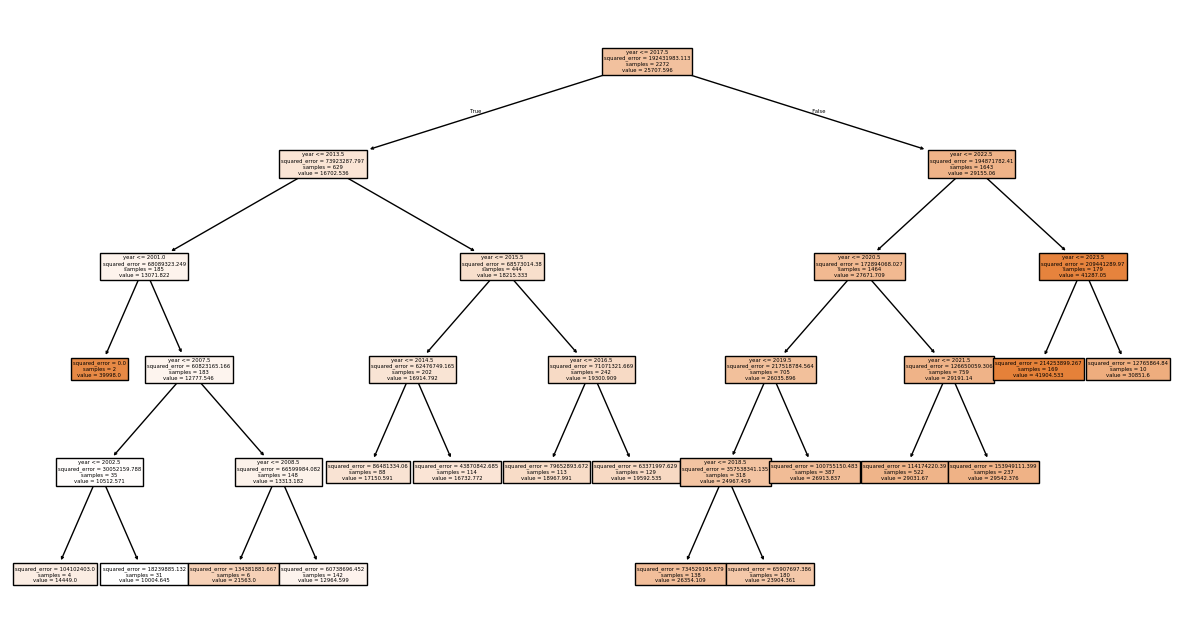

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

df = pd.read_csv("/content/car_web_scraped_dataset.csv")
df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

X = df[["year"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor(max_depth=5, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

print("Predicted Price:", model.predict([[2022]])[0])


plt.figure(figsize=(15, 8))
plot_tree(model, feature_names=["year"], filled=True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("/content/car_web_scraped_dataset.csv")

df["miles"] = df["miles"].str.replace(" miles", "").str.replace(",", "").astype(float)
df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

X = df[["year", "miles"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

svm = SVR(kernel="rbf")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: -0.025005398159762438
Mean Squared Error: 162437997.50170806


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("car_web_scraped_dataset.csv")

df["miles"] = df["miles"].str.replace(" miles", "", regex=False)
df["miles"] = df["miles"].str.replace(",", "", regex=False)
df["miles"] = pd.to_numeric(df["miles"])

df["price"] = df["price"].str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = pd.to_numeric(df["price"])

le_name = LabelEncoder()
le_color = LabelEncoder()
le_condition = LabelEncoder()

df["name"] = le_name.fit_transform(df["name"])
df["color"] = le_color.fit_transform(df["color"])
df["condition"] = le_condition.fit_transform(df["condition"])

median_price = df["price"].median()

df["price_category"] = (df["price"] >= median_price).astype(int)

X = df[["name", "year", "miles", "color", "condition"]]

y = df["price_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7464788732394366

Confusion Matrix:
[[175 102]
 [ 42 249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       277
           1       0.71      0.86      0.78       291

    accuracy                           0.75       568
   macro avg       0.76      0.74      0.74       568
weighted avg       0.76      0.75      0.74       568



R2 Score: 0.32425151614278536
Mean Squared Error: 107089417.02126761


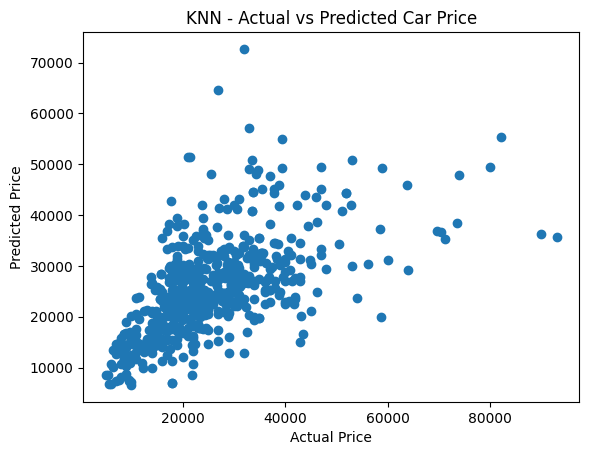

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("/content/car_web_scraped_dataset.csv")

df["miles"] = df["miles"].str.replace(" miles", "").str.replace(",", "").astype(float)

df["price"] = df["price"].str.replace("$", "").str.replace(",", "").astype(float)

X = df[["year", "miles"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN - Actual vs Predicted Car Price")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

df = pd.read_csv("car_web_scraped_dataset.csv")

df["miles"] = df["miles"].str.replace(" miles", "", regex=False)
df["miles"] = df["miles"].str.replace(",", "", regex=False)
df["miles"] = pd.to_numeric(df["miles"])

df["price"] = df["price"].str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = pd.to_numeric(df["price"])

name_encoder = LabelEncoder()
color_encoder = LabelEncoder()
condition_encoder = LabelEncoder()

df["name"] = name_encoder.fit_transform(df["name"])
df["color"] = color_encoder.fit_transform(df["color"])
df["condition"] = condition_encoder.fit_transform(df["condition"])

median_price = df["price"].median()

df["price_category"] = (
    df["price"] >= median_price
).astype(int)

X = df[[
    "name",
    "year",
    "miles",
    "color",
    "condition"
]]

y = df["price_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8767605633802817

Confusion Matrix:
[[246  38]
 [ 32 252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       284
           1       0.87      0.89      0.88       284

    accuracy                           0.88       568
   macro avg       0.88      0.88      0.88       568
weighted avg       0.88      0.88      0.88       568

